In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nyc-taxi-trip-duration/train.zip
/kaggle/input/nyc-taxi-trip-duration/test.zip
/kaggle/input/nyc-taxi-trip-duration/sample_submission.zip


The evaluation metric for this competition is Root Mean Squared Logarithmic Error.

# Final

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
import xgboost as xgb

In [3]:
N = 100000 # number of sample rows in plots

# Data

In [4]:
train = pd.read_csv('/kaggle/input/nyc-taxi-trip-duration/train.zip')
test = pd.read_csv('/kaggle/input/nyc-taxi-trip-duration/test.zip')

In [5]:
test_ids = test['id'].copy()

In [6]:
train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


Idea of how this values look

In [7]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
train.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1458644.000,1458644.000,1458644.000,1458644.000,1458644.000,1458644.000,1458644.000
mean,1.535,1.665,-73.973,40.751,-73.973,40.752,959.492
std,0.499,1.314,0.071,0.033,0.071,0.036,5237.432
min,1.000,0.000,-121.933,34.360,-121.933,32.181,1.000
25%,1.000,1.000,-73.992,40.737,-73.991,40.736,397.000
50%,2.000,1.000,-73.982,40.754,-73.980,40.755,662.000
75%,2.000,2.000,-73.967,40.768,-73.963,40.770,1075.000
max,2.000,9.000,-61.336,51.881,-61.336,43.921,3526282.000


Outliers:
* Trip duration:
    * Max: 960 hours
  * Min: 1 sec

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [9]:
train.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

# Target

In [10]:
test.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
dtype: int64

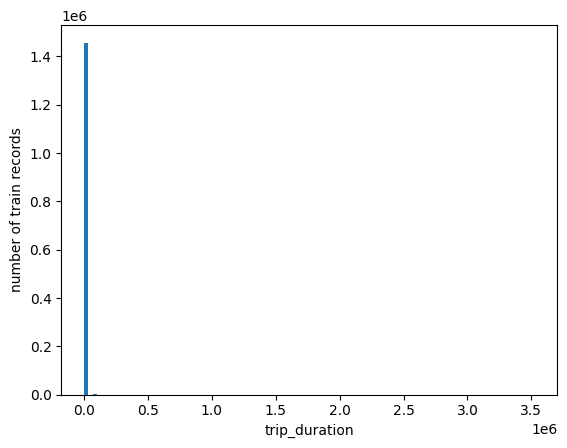

In [11]:
plt.hist(train['trip_duration'].values, bins=100)
plt.xlabel('trip_duration')
plt.ylabel('number of train records')
plt.show()

In [12]:
# Clean Trip duration outliers

train = train[train['trip_duration'] >= 60]
train = train[train['trip_duration'] <= 14400] 

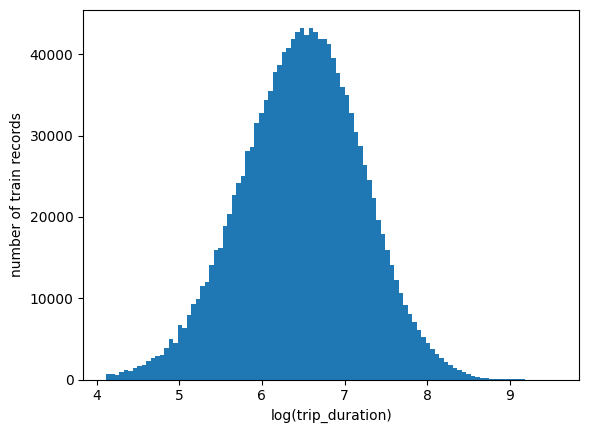

In [13]:
train['log_trip_duration'] = np.log(train['trip_duration'].values + 1)
plt.hist(train['log_trip_duration'].values, bins=100)
plt.xlabel('log(trip_duration)')
plt.ylabel('number of train records')
plt.show()

In [14]:
print("Valores esperados de log_trip_duration:")
print(f"  log(60+1)   = {np.log(61):.3f}   ← mínimo esperado")
print(f"  log(662+1)  = {np.log(663):.3f}   ← mediana esperada") 
print(f"  log(14400+1)= {np.log(14401):.3f}  ← máximo esperado")
print()
print("Tu distribución actual:")
print(train['log_trip_duration'].describe())

Valores esperados de log_trip_duration:
  log(60+1)   = 4.111   ← mínimo esperado
  log(662+1)  = 6.497   ← mediana esperada
  log(14400+1)= 9.575  ← máximo esperado

Tu distribución actual:
count   1447972.000
mean          6.480
std           0.729
min           4.111
25%           5.996
50%           6.501
75%           6.982
max           9.564
Name: log_trip_duration, dtype: float64


# Data Cleaning

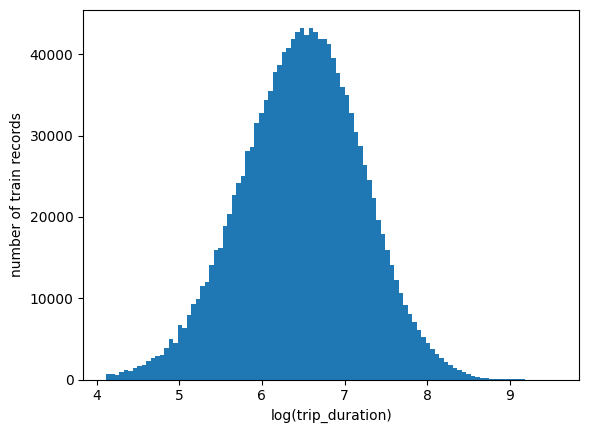

In [15]:
# Check new values

plt.hist(train['log_trip_duration'].values, bins=100)
plt.xlabel('log(trip_duration)')
plt.ylabel('number of train records')
plt.show()

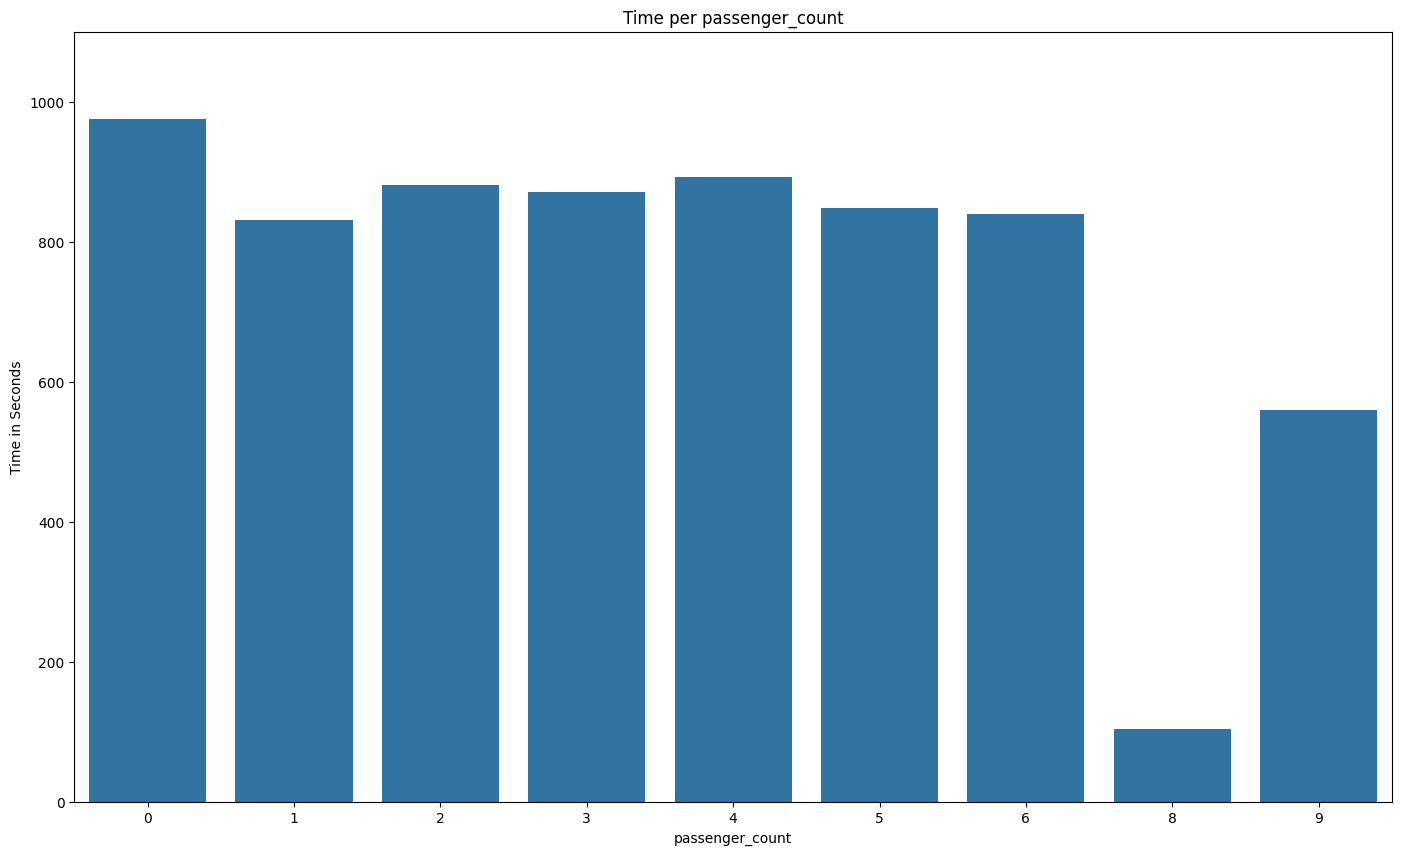

In [16]:
pc = train.groupby('passenger_count')['trip_duration'].mean()

plt.figure(figsize=(17,10))
plt.ylim(0, 1100)
plt.title('Time per passenger_count')
plt.ylabel('Time in Seconds')

sns.barplot(x=pc.index, y=pc.values)

plt.show()


In [17]:
# City limits
train = train[
    (train.pickup_longitude > -74.03) &
    (train.pickup_longitude < -73.75) &
    (train.pickup_latitude > 40.63) &
    (train.pickup_latitude < 40.85)
]

train = train[
    (train.dropoff_longitude > -74.03) &
    (train.dropoff_longitude < -73.75) &
    (train.dropoff_latitude > 40.63) &
    (train.dropoff_latitude < 40.85)
]

# Transform PCA
coords_train = np.vstack((train[['pickup_latitude', 'pickup_longitude']].values,
                          train[['dropoff_latitude', 'dropoff_longitude']].values))

pca = PCA().fit(coords_train)
train['pickup_pca0'] = pca.transform(train[['pickup_latitude', 'pickup_longitude']])[:, 0]
train['pickup_pca1'] = pca.transform(train[['pickup_latitude', 'pickup_longitude']])[:, 1]
train['dropoff_pca0'] = pca.transform(train[['dropoff_latitude', 'dropoff_longitude']])[:, 0]
train['dropoff_pca1'] = pca.transform(train[['dropoff_latitude', 'dropoff_longitude']])[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


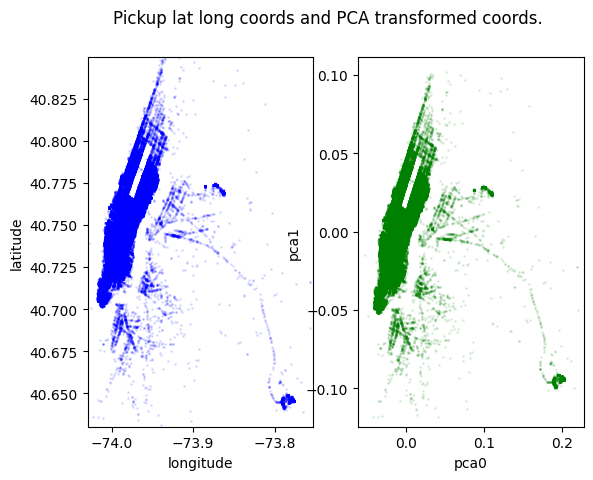

In [18]:
city_long_border = (
    train['pickup_longitude'].min(),
    train['pickup_longitude'].max()
)

city_lat_border = (
    train['pickup_latitude'].min(),
    train['pickup_latitude'].max()
)


fig, ax = plt.subplots(ncols=2)
ax[0].scatter(train['pickup_longitude'].values[:N], train['pickup_latitude'].values[:N],
              color='blue', s=1, alpha=0.1)
ax[1].scatter(train['pickup_pca0'].values[:N], train['pickup_pca1'].values[:N],
              color='green', s=1, alpha=0.1)
fig.suptitle('Pickup lat long coords and PCA transformed coords.')
ax[0].set_ylabel('latitude')
ax[0].set_xlabel('longitude')
ax[1].set_xlabel('pca0')
ax[1].set_ylabel('pca1')
ax[0].set_xlim(city_long_border)
ax[0].set_ylim(city_lat_border)
pca_borders = pca.transform([[x, y] for x in city_lat_border for y in city_long_border])
ax[1].set_xlim(pca_borders[:, 0].min(), pca_borders[:, 0].max())
ax[1].set_ylim(pca_borders[:, 1].min(), pca_borders[:, 1].max())
plt.show()

In [19]:
print(pca.components_)


[[-0.05835417  0.99829594]
 [ 0.99829594  0.05835417]]


In [20]:
train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,log_trip_duration,pickup_pca0,pickup_pca1,dropoff_pca0,dropoff_pca1
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982,40.768,-73.965,40.766,N,455,6.122,-0.009,0.016,0.008,0.015
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980,40.739,-73.999,40.731,N,663,6.498,-0.006,-0.013,-0.024,-0.022
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979,40.764,-74.005,40.710,N,2124,7.662,-0.006,0.012,-0.029,-0.043
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010,40.720,-74.012,40.707,N,429,6.064,-0.034,-0.033,-0.036,-0.047
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973,40.793,-73.973,40.783,N,435,6.078,-0.002,0.042,-0.001,0.031


# Feature Engineering

In [21]:
train['pickup_datetime'] = pd.to_datetime(train.pickup_datetime)
train.loc[:, 'pickup_date'] = train['pickup_datetime'].dt.date
train['dropoff_datetime'] = pd.to_datetime(train.dropoff_datetime)

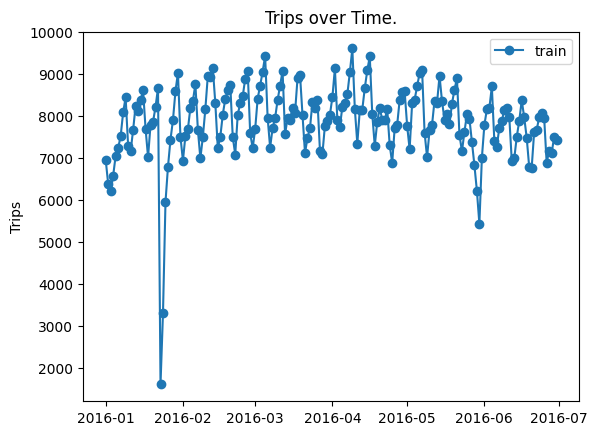

In [22]:
plt.plot(train.groupby('pickup_date').count()[['id']], 'o-', label='train')
# plt.plot(test.groupby('pickup_date').count()[['id']], 'o-', label='test')
plt.title('Trips over Time.')
plt.legend(loc=0)
plt.ylabel('Trips')
plt.show()

In [23]:
train['Month'] = train['pickup_datetime'].dt.month

train['DayofMonth'] = train['pickup_datetime'].dt.day

train['Hour'] = train['pickup_datetime'].dt.hour

train['dayofweek'] = train['pickup_datetime'].dt.dayofweek

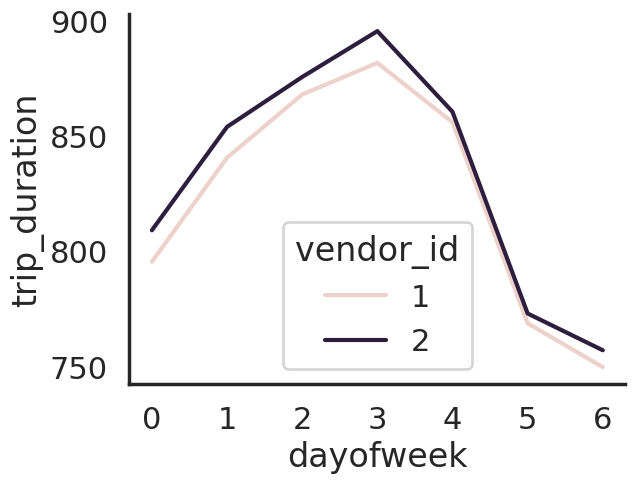

In [24]:
summary_wdays_avg_duration = (
    train.groupby(['vendor_id','dayofweek'])['trip_duration']
    .mean()
    .reset_index()
)

sns.set(style="white", palette="muted", color_codes=True)
sns.set_context("poster")

sns.lineplot(
    data=summary_wdays_avg_duration,
    x="dayofweek",
    y="trip_duration",
    hue="vendor_id"
)
plt.xticks(sorted(summary_wdays_avg_duration['dayofweek'].unique()))

sns.despine(bottom=False)
plt.show()


<Figure size 640x480 with 0 Axes>

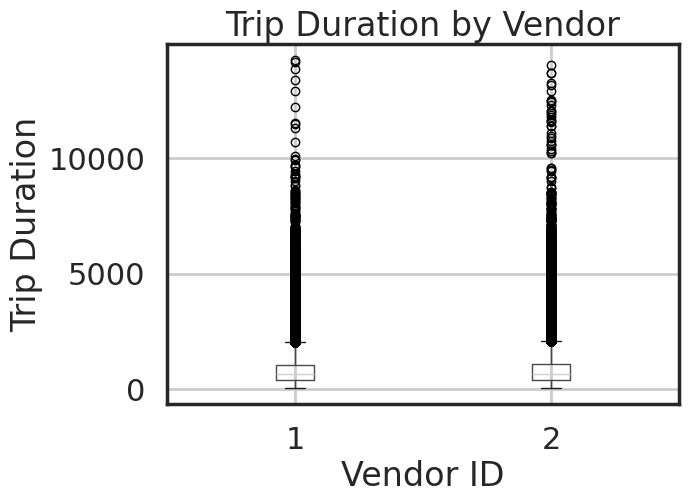

In [25]:
plt.figure()
train.boxplot(column='trip_duration', by='vendor_id')
plt.title('Trip Duration by Vendor')
plt.suptitle('')
plt.xlabel('Vendor ID')
plt.ylabel('Trip Duration')
plt.show()

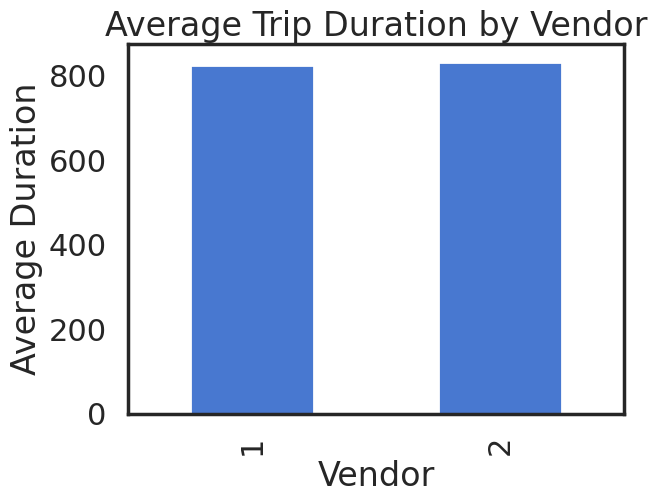

In [26]:
train.groupby('vendor_id')['trip_duration'].mean().plot(kind='bar')
plt.title('Average Trip Duration by Vendor')
plt.xlabel('Vendor')
plt.ylabel('Average Duration')
plt.show()

<Figure size 640x480 with 0 Axes>

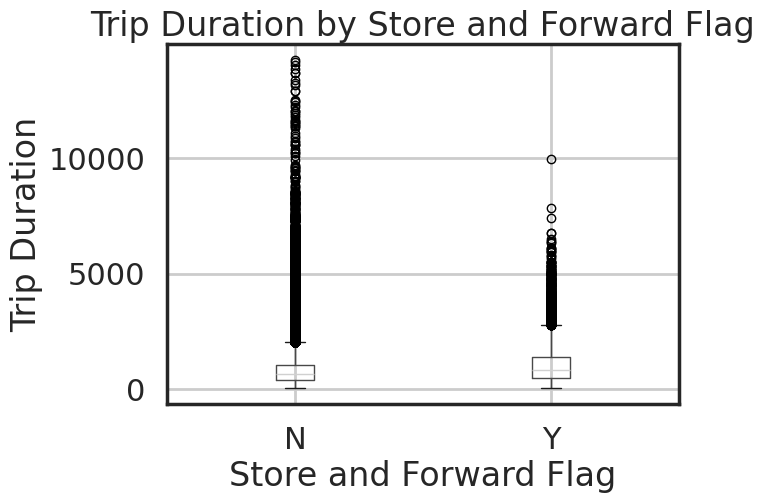

In [27]:
plt.figure()
train.boxplot(column='trip_duration', by='store_and_fwd_flag')
plt.title('Trip Duration by Store and Forward Flag')
plt.suptitle('')
plt.xlabel('Store and Forward Flag')
plt.ylabel('Trip Duration')
plt.show()

In [28]:
def haversine_array(lat1, lng1, lat2, lng2):
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    AVG_EARTH_RADIUS = 6371  # in km
    lat = lat2 - lat1
    lng = lng2 - lng1
    d = np.sin(lat * 0.5) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng * 0.5) ** 2
    h = 2 * AVG_EARTH_RADIUS * np.arcsin(np.sqrt(d))
    return h

def dummy_manhattan_distance(lat1, lng1, lat2, lng2):
    a = haversine_array(lat1, lng1, lat1, lng2)
    b = haversine_array(lat1, lng1, lat2, lng1)
    return a + b

def bearing_array(lat1, lng1, lat2, lng2):
    AVG_EARTH_RADIUS = 6371  # in km
    lng_delta_rad = np.radians(lng2 - lng1)
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    y = np.sin(lng_delta_rad) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(lng_delta_rad)
    return np.degrees(np.arctan2(y, x))

In [29]:
train.loc[:, 'distance_haversine'] = haversine_array(train['pickup_latitude'].values, train['pickup_longitude'].values, train['dropoff_latitude'].values, train['dropoff_longitude'].values)

    
train.loc[:, 'distance_dummy_manhattan'] =  dummy_manhattan_distance(train['pickup_latitude'].values, train['pickup_longitude'].values, train['dropoff_latitude'].values, train['dropoff_longitude'].values)

train.loc[:, 'direction'] = bearing_array(train['pickup_latitude'].values, train['pickup_longitude'].values, train['dropoff_latitude'].values, train['dropoff_longitude'].values)

In [30]:
print(train.dtypes)

id                                  object
vendor_id                            int64
pickup_datetime             datetime64[ns]
dropoff_datetime            datetime64[ns]
passenger_count                      int64
pickup_longitude                   float64
pickup_latitude                    float64
dropoff_longitude                  float64
dropoff_latitude                   float64
store_and_fwd_flag                  object
trip_duration                        int64
log_trip_duration                  float64
pickup_pca0                        float64
pickup_pca1                        float64
dropoff_pca0                       float64
dropoff_pca1                       float64
pickup_date                         object
Month                                int32
DayofMonth                           int32
Hour                                 int32
dayofweek                            int32
distance_haversine                 float64
distance_dummy_manhattan           float64
direction  

In [31]:
train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,dropoff_pca0,dropoff_pca1,pickup_date,Month,DayofMonth,Hour,dayofweek,distance_haversine,distance_dummy_manhattan,direction
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982,40.768,-73.965,40.766,N,...,0.008,0.015,2016-03-14,3,14,17,0,1.499,1.735,99.970
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980,40.739,-73.999,40.731,N,...,-0.024,-0.022,2016-06-12,6,12,0,6,1.806,2.431,-117.154
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979,40.764,-74.005,40.710,N,...,-0.029,-0.043,2016-01-19,1,19,11,1,6.385,8.204,-159.680
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010,40.720,-74.012,40.707,N,...,-0.036,-0.047,2016-04-06,4,6,19,2,1.485,1.661,-172.738
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973,40.793,-73.973,40.783,N,...,-0.001,0.031,2016-03-26,3,26,13,5,1.189,1.199,179.474


In [32]:
coords_train = np.vstack((train[['pickup_latitude', 'pickup_longitude']].values,
                          train[['dropoff_latitude', 'dropoff_longitude']].values))

In [33]:
sample_ind = np.random.permutation(len(coords_train))[:500000] 
kmeans = MiniBatchKMeans(n_clusters=30, batch_size=10000).fit(coords_train[sample_ind])


In [34]:
train.loc[:, 'pickup_cluster'] = kmeans.predict(train[['pickup_latitude', 'pickup_longitude']])
train.loc[:, 'dropoff_cluster'] = kmeans.predict(train[['dropoff_latitude', 'dropoff_longitude']])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(


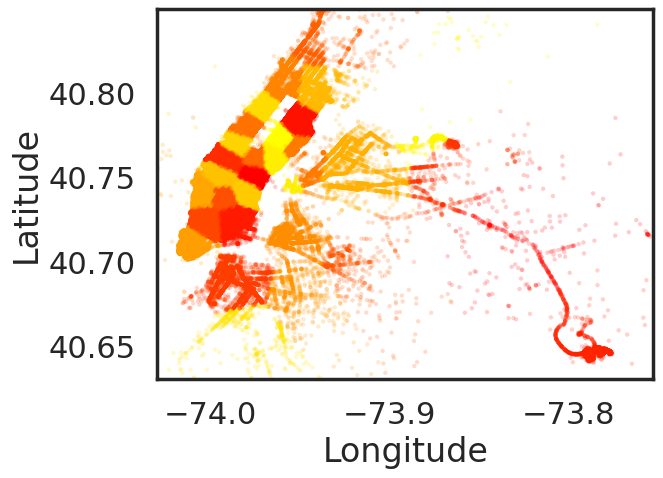

In [35]:
fig, ax = plt.subplots(ncols=1, nrows=1)
ax.scatter(train.pickup_longitude.values[:500000], train.pickup_latitude.values[:500000], s=10, lw=0,
           c=train.pickup_cluster[:500000].values, cmap='autumn', alpha=0.2)
ax.set_xlim(city_long_border)
ax.set_ylim(city_lat_border)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

In [36]:
print(train.dtypes)

id                                  object
vendor_id                            int64
pickup_datetime             datetime64[ns]
dropoff_datetime            datetime64[ns]
passenger_count                      int64
pickup_longitude                   float64
pickup_latitude                    float64
dropoff_longitude                  float64
dropoff_latitude                   float64
store_and_fwd_flag                  object
trip_duration                        int64
log_trip_duration                  float64
pickup_pca0                        float64
pickup_pca1                        float64
dropoff_pca0                       float64
dropoff_pca1                       float64
pickup_date                         object
Month                                int32
DayofMonth                           int32
Hour                                 int32
dayofweek                            int32
distance_haversine                 float64
distance_dummy_manhattan           float64
direction  

In [37]:
train = train.sort_values('pickup_datetime')

In [38]:
split_date = train['pickup_datetime'].quantile(0.8)

train_set = train[train['pickup_datetime'] < split_date].copy()
valid_set = train[train['pickup_datetime'] >= split_date].copy()

In [39]:
cols_to_drop = ['id', 'pickup_datetime', 'dropoff_datetime', 'pickup_date', 'trip_duration']

train_set.drop(columns=[c for c in cols_to_drop if c in train_set.columns], inplace=True)
valid_set.drop(columns=[c for c in cols_to_drop if c in valid_set.columns], inplace=True)

In [40]:
categorical_cols = ['vendor_id', 'store_and_fwd_flag', 'pickup_cluster', 'dropoff_cluster']
categorical_cols = [c for c in categorical_cols if c in train_set.columns]

train_set = pd.get_dummies(train_set, columns=categorical_cols, drop_first=False)
valid_set = pd.get_dummies(valid_set, columns=categorical_cols, drop_first=False)

# Modelo

## Hacer exactamente lo mismo para test


In [41]:
train_set, valid_set = train_set.align(valid_set, join='left', axis=1, fill_value=0)

In [42]:
X_train = train_set.drop('log_trip_duration', axis=1)
y_train = train_set['log_trip_duration']

X_valid = valid_set.drop('log_trip_duration', axis=1)
y_valid = valid_set['log_trip_duration']

print("Train shape:", X_train.shape)
print("Valid shape:", X_valid.shape)


Train shape: (1143284, 80)
Valid shape: (285821, 80)


In [43]:
# --- Asegurarse de que test tenga los mismos tipos y transformaciones que train ---

# 1. Distancias y dirección
test['distance_haversine'] = haversine_array(
    test['pickup_latitude'], test['pickup_longitude'],
    test['dropoff_latitude'], test['dropoff_longitude']
)

test['distance_dummy_manhattan'] = dummy_manhattan_distance(
    test['pickup_latitude'], test['pickup_longitude'],
    test['dropoff_latitude'], test['dropoff_longitude']
)

test['direction'] = bearing_array(
    test['pickup_latitude'], test['pickup_longitude'],
    test['dropoff_latitude'], test['dropoff_longitude']
)


# 3. Date features
test['pickup_datetime'] = pd.to_datetime(test['pickup_datetime'])
test['Month'] = test['pickup_datetime'].dt.month
test['DayofMonth'] = test['pickup_datetime'].dt.day
test['Hour'] = test['pickup_datetime'].dt.hour
test['dayofweek'] = test['pickup_datetime'].dt.dayofweek

# Clippear coordenadas del test al mismo rango que el train (sin borrar filas)
test['pickup_longitude']  = test['pickup_longitude'].clip(-74.03, -73.75)
test['pickup_latitude']   = test['pickup_latitude'].clip(40.63, 40.85)
test['dropoff_longitude'] = test['dropoff_longitude'].clip(-74.03, -73.75)
test['dropoff_latitude']  = test['dropoff_latitude'].clip(40.63, 40.85)

# Recalcular distancias y dirección después del clip
test['distance_haversine'] = haversine_array(
    test['pickup_latitude'], test['pickup_longitude'],
    test['dropoff_latitude'], test['dropoff_longitude']
)
test['distance_dummy_manhattan'] = dummy_manhattan_distance(
    test['pickup_latitude'], test['pickup_longitude'],
    test['dropoff_latitude'], test['dropoff_longitude']
)
test['direction'] = bearing_array(
    test['pickup_latitude'], test['pickup_longitude'],
    test['dropoff_latitude'], test['dropoff_longitude']
)

# Ahora sí aplicar PCA y clusters con coordenadas ya limpias
test['pickup_pca0'] = pca.transform(test[['pickup_latitude','pickup_longitude']])[:,0]
test['pickup_pca1'] = pca.transform(test[['pickup_latitude','pickup_longitude']])[:,1]
test['dropoff_pca0'] = pca.transform(test[['dropoff_latitude','dropoff_longitude']])[:,0]
test['dropoff_pca1'] = pca.transform(test[['dropoff_latitude','dropoff_longitude']])[:,1]

test['pickup_cluster']  = kmeans.predict(test[['pickup_latitude','pickup_longitude']])
test['dropoff_cluster'] = kmeans.predict(test[['dropoff_latitude','dropoff_longitude']])

# 6. One-hot encoding usando las mismas columnas que en train
categorical_cols = ['vendor_id','store_and_fwd_flag','pickup_cluster','dropoff_cluster']
test = pd.get_dummies(test, columns=categorical_cols, drop_first=False)

# 7. Dropear columnas innecesarias
drop_cols = ['pickup_datetime','dropoff_datetime','pickup_date', 'avg_speed_h', 'avg_speed_m']
for c in drop_cols:
    if c in test.columns:
        test.drop(c, axis=1, inplace=True)

# 8. Alinear columnas con train (si alguna categoría no existe en test, agregar columna con 0)
for col in X_train.columns:  # X_train es tu dataset de entrenamiento final
    if col not in test.columns:
       test[col] = 0

# Asegurarse de que el orden de columnas sea igual a X_train
test = test[X_train.columns]

# 9. Crear DMatrix para XGBoost
dtest = xgb.DMatrix(test)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MiniBatchKMeans was fitted without feature nam

In [44]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_valid, label=y_valid)
dtest = xgb.DMatrix(test)  # sin label

In [45]:
watchlist = [(dtrain, 'train'), (dvalid, 'valid')]

In [46]:
xgb_pars = {
    'min_child_weight': 5,
    'eta': 0.05,
    'colsample_bytree': 0.8,
    'max_depth': 8,
    'subsample': 0.8,
    'lambda': 1.0,
    'alpha': 0.1,
    'nthread': -1,
    'eval_metric': 'rmse',
    'objective': 'reg:squarederror'
}

model = xgb.train(
    xgb_pars,
    dtrain,
    num_boost_round=2000,
    evals=watchlist,
    early_stopping_rounds=50,
    verbose_eval=100
)


[0]	train-rmse:0.69403	valid-rmse:0.71446
[100]	train-rmse:0.32412	valid-rmse:0.34400
[200]	train-rmse:0.30891	valid-rmse:0.33424
[300]	train-rmse:0.30145	valid-rmse:0.33006
[400]	train-rmse:0.29607	valid-rmse:0.32745
[500]	train-rmse:0.29165	valid-rmse:0.32567
[600]	train-rmse:0.28780	valid-rmse:0.32465
[700]	train-rmse:0.28447	valid-rmse:0.32357
[800]	train-rmse:0.28117	valid-rmse:0.32282
[900]	train-rmse:0.27848	valid-rmse:0.32226
[1000]	train-rmse:0.27594	valid-rmse:0.32183
[1100]	train-rmse:0.27364	valid-rmse:0.32143
[1200]	train-rmse:0.27145	valid-rmse:0.32115
[1300]	train-rmse:0.26933	valid-rmse:0.32081
[1400]	train-rmse:0.26731	valid-rmse:0.32060
[1500]	train-rmse:0.26540	valid-rmse:0.32038
[1570]	train-rmse:0.26414	valid-rmse:0.32032


In [47]:
from sklearn.metrics import mean_squared_log_error

pred_valid = model.predict(dvalid)
rmsle_real = np.sqrt(np.mean((pred_valid - y_valid.values) ** 2))
print("Validation RMSLE:", rmsle_real)

Validation RMSLE: 0.32032447149154786


In [48]:
pred_test = model.predict(dtest, iteration_range=(0, model.best_iteration + 1))

import numpy as np
pred_test = np.expm1(pred_test)

In [49]:
pred_test_log = model.predict(dtest, iteration_range=(0, model.best_iteration + 1))

# Verificación obligatoria antes de exportar
print("Rango de predicciones en escala log (esperado: ~5 a ~9):")
print(f"  min={pred_test_log.min():.3f}, max={pred_test_log.max():.3f}, mean={pred_test_log.mean():.3f}")

pred_test_duration = np.expm1(pred_test_log)

print("\nRango de predicciones en segundos (esperado: ~60 a ~5000):")
print(f"  min={pred_test_duration.min():.1f}, max={pred_test_duration.max():.1f}, mean={pred_test_duration.mean():.1f}")

# Verificar que no haya valores negativos o absurdos
assert pred_test_duration.min() > 0, "Hay predicciones negativas — algo está mal"
assert pred_test_duration.max() < 100000, "Hay predicciones absurdamente altas — algo está mal"

submission = pd.DataFrame({
    "id": test_ids,
    "trip_duration": pred_test_duration
})

submission.to_csv("submission.csv", index=False)
print("\nPrimeras filas del submission:")
print(submission.head(10))

Rango de predicciones en escala log (esperado: ~5 a ~9):
  min=3.753, max=8.700, mean=6.474

Rango de predicciones en segundos (esperado: ~60 a ~5000):
  min=41.7, max=6000.6, mean=804.8

Primeras filas del submission:
          id  trip_duration
0  id3004672        879.331
1  id3505355        550.087
2  id1217141        434.342
3  id2150126        942.407
4  id1598245        377.317
5  id0668992       1024.501
6  id1765014       1162.808
7  id0898117        724.379
8  id3905224       2520.933
9  id1543102        571.174


In [50]:
print("Distribución log_trip_duration en train_set:")
print(y_train.describe())

print("\nDistución predicciones log en test:")
import pandas as pd
print(pd.Series(pred_test_log).describe())

Distribución log_trip_duration en train_set:
count   1143284.000
mean          6.458
std           0.719
min           4.111
25%           5.981
50%           6.482
75%           6.955
max           9.564
Name: log_trip_duration, dtype: float64

Distución predicciones log en test:
count   625134.000
mean         6.474
std          0.662
min          3.753
25%          6.008
50%          6.480
75%          6.940
max          8.700
dtype: float64


In [51]:
print("=== COMPARACIÓN DE FEATURES TRAIN vs TEST ===")
print("\nX_train stats:")
print(X_train[['distance_haversine', 'distance_dummy_manhattan', 'Hour', 'pickup_pca0']].describe())

print("\ntest stats:")
print(test[['distance_haversine', 'distance_dummy_manhattan', 'Hour', 'pickup_pca0']].describe())

=== COMPARACIÓN DE FEATURES TRAIN vs TEST ===

X_train stats:
       distance_haversine  distance_dummy_manhattan        Hour  pickup_pca0
count         1143284.000               1143284.000 1143284.000  1143284.000
mean                3.290                     4.255      13.633       -0.000
std                 3.642                     4.872       6.365        0.037
min                 0.000                     0.000       0.000       -0.058
25%                 1.231                     1.569       9.000       -0.018
50%                 2.070                     2.658      14.000       -0.008
75%                 3.761                     4.856      19.000        0.005
max                27.192                    38.237      23.000        0.221

test stats:
       distance_haversine  distance_dummy_manhattan       Hour  pickup_pca0
count          625134.000                625134.000 625134.000   625134.000
mean                3.384                     4.373     13.610        0.000
std 

In [52]:
# ¿Las distancias del test tienen sentido?
print("Distancias en test (esperado: 0.5 a 30 km):")
print(test['distance_haversine'].describe())

print("\nDistancias en train (referencia):")
print(X_train['distance_haversine'].describe())

# ¿El modelo usa distance_haversine como feature importante?
importance = model.get_score(importance_type='gain')
top_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 features por importancia:")
for feat, score in top_features:
    print(f"  {feat}: {score:.1f}")

Distancias en test (esperado: 0.5 a 30 km):
count   625134.000
mean         3.384
std          3.776
min          0.000
25%          1.232
50%          2.093
75%          3.874
max         30.953
Name: distance_haversine, dtype: float64

Distancias en train (referencia):
count   1143284.000
mean          3.290
std           3.642
min           0.000
25%           1.231
50%           2.070
75%           3.761
max          27.192
Name: distance_haversine, dtype: float64

Top 10 features por importancia:
  distance_haversine: 110.8
  distance_dummy_manhattan: 40.2
  Hour: 9.4
  direction: 7.6
  pickup_cluster_12: 7.5
  dayofweek: 7.3
  dropoff_cluster_18: 6.8
  dropoff_cluster_5: 5.7
  dropoff_pca1: 5.6
  dropoff_cluster_3: 4.8


In [53]:
submission = pd.DataFrame({
    "id": test_ids,
    "trip_duration": pred_test
})

submission.to_csv("submission.csv", index=False)
